In [1]:
from datasets import load_from_disk
dataset = load_from_disk("/home/christian/vae/data_nb_1b_combined")

/home/christian/vae/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from collections import defaultdict
import random

indices_by_length = defaultdict(list)
for idx, example in enumerate(dataset):
    indices_by_length[len(example["s"])].append(idx)
print("fpd")

length_counts = {length: len(indices) for length, indices in indices_by_length.items()}
print("spd")

for length in indices_by_length:
    random.shuffle(indices_by_length[length])
print("tpd")

capped_length = 50000
selected_indices = []
for length, count in length_counts.items():
    num_samples = min(count, capped_length)
    selected_indices.extend(indices_by_length[length][:num_samples])
print("qpd")

new_dataset = dataset.select(selected_indices)
new_dataset.save_to_disk("/home/christian/vae/data_nb_1b_combined_capped_50k")

fpd
spd
tpd
qpd


Saving the dataset (3/3 shards): 100%|██████████| 5131588/5131588 [00:15<00:00, 337863.74 examples/s]


In [2]:
lengths = [len(example["s"]) for example in dataset]

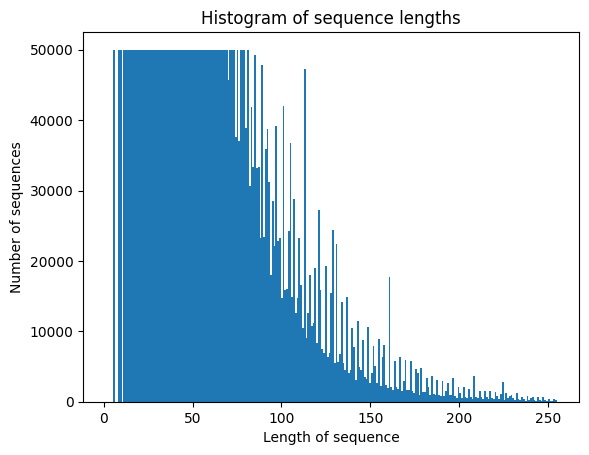

In [3]:
from datasets import load_from_disk
dataset = load_from_disk("/home/christian/vae/data_nb_1b_combined_capped_50k")
lengths = [len(example["s"]) for example in dataset]
import matplotlib.pyplot as plt
plt.hist(lengths, bins=255)
plt.xlabel("Length of sequence")
plt.ylabel("Number of sequences")
plt.title("Histogram of sequence lengths")
plt.show()

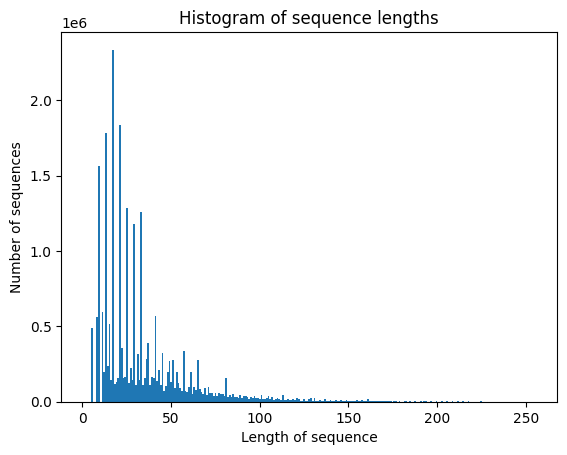

In [4]:
import matplotlib.pyplot as plt
plt.hist(lengths, bins=255)
plt.xlabel("Length of sequence")
plt.ylabel("Number of sequences")
plt.title("Histogram of sequence lengths")
plt.show()

In [5]:
print(min(lengths), max(lengths), sum(lengths) / len(lengths), len(lengths))

1 255 33.88573044544499 24286119


In [6]:
n = 100
pct_over_n = sum(l > n for l in lengths) / len(lengths) * 100
print(f"{pct_over_n:.2f}% seq > len {n}")

3.63% seq > len 100


In [8]:
print(dataset[1])

{'s': [190, 15, 115, 131, 39, 114, 131, 42, 121, 127, 45, 123, 127, 37, 113, 131, 191, 46, 118, 130, 192, 43, 104, 129, 196, 22, 115, 133, 198, 48, 113, 130, 39, 106, 130, 44, 114, 130, 41, 112, 129, 203, 27, 109, 134, 204, 41, 116, 127, 46, 123, 127, 43, 115, 127, 49, 116, 127, 212, 22, 116, 129, 215, 27, 114, 130, 220, 39, 114, 134, 42, 125, 126, 15, 113, 134, 46, 118, 134, 37, 117, 133, 45, 106, 126, 43, 114, 134, 2]}


In [9]:
length_counts = {}
for l in lengths:
    if l not in length_counts:
        length_counts[l] = 0
    length_counts[l] += 1

In [10]:
print(length_counts)

{1: 1, 89: 47783, 62: 53011, 81: 154713, 60: 97030, 65: 275869, 48: 194374, 51: 276747, 21: 1839646, 41: 568567, 44: 113429, 37: 389752, 59: 67367, 100: 14792, 38: 113195, 43: 213120, 36: 282712, 52: 93010, 88: 23311, 64: 77170, 40: 154655, 47: 105292, 114: 9014, 32: 146229, 50: 131128, 46: 73683, 76: 37074, 25: 1284622, 29: 1182788, 13: 1780711, 17: 2336547, 33: 1259395, 24: 164593, 20: 159383, 9: 1561590, 61: 194367, 80: 38913, 53: 195558, 49: 273258, 57: 335570, 5: 489709, 35: 159803, 34: 113199, 30: 113306, 22: 354447, 39: 166922, 69: 92935, 18: 114752, 31: 314545, 12: 198130, 16: 142944, 45: 326254, 8: 560236, 15: 514676, 42: 134619, 56: 70221, 27: 226454, 54: 125879, 102: 15930, 63: 96390, 108: 12636, 111: 16647, 105: 36748, 99: 23295, 97: 39189, 84: 33319, 90: 23343, 67: 61976, 58: 71224, 72: 58385, 70: 45641, 120: 8289, 85: 49299, 93: 31253, 106: 14837, 118: 11163, 94: 17953, 96: 22095, 101: 42066, 77: 56966, 91: 35906, 95: 28521, 98: 22825, 107: 28846, 127: 6868, 110: 23223, 1